# BCB All Types: Eigenvalue Count Analysis

This notebook stacks the spectral outputs from BCB clone types and non-clone, deduplicates by `method_id` and `graph_type`, and studies how many eigenvalues each code graph has.

In [1]:
from __future__ import annotations

import json
import pickle
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "spectral_code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import output_root_for

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]
BCB_VARIANTS = [
    {"label": "Type 1", "variant": "1"},
    {"label": "Type 2", "variant": "2"},
    {"label": "Type 3 All", "variant": "3/all"},
    {"label": "Type 4", "variant": "4"},
    {"label": "Non Clone", "variant": "non_clone"},
]

def spectral_manifest_path(variant: str) -> Path:
    return output_root_for("bcb", variant) / "spectral_features" / "spectral_features_manifest.json"

manifest_rows = []
for config in BCB_VARIANTS:
    path = spectral_manifest_path(config["variant"])
    manifest_rows.append({
        "label": config["label"],
        "variant": config["variant"],
        "manifest_path": str(path),
        "exists": path.exists(),
    })

manifest_df = pd.DataFrame(manifest_rows)
display(manifest_df)

missing = manifest_df[~manifest_df["exists"]]
if not missing.empty:
    raise FileNotFoundError("Missing spectral manifests:\n" + "\n".join(missing["manifest_path"]))

c:\Users\koush\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,label,variant,manifest_path,exists
0,Type 1,1,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
1,Type 2,2,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
2,Type 3 All,3/all,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
3,Type 4,4,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
4,Non Clone,non_clone,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True


## Load Eigenvalue Counts

In [2]:
def finite_eigenvalue_count(values) -> int:
    arr = np.asarray(values, dtype=np.float64).ravel()
    return int(np.isfinite(arr).sum())

def iter_spectral_count_rows(config: dict):
    manifest_path = spectral_manifest_path(config["variant"])
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    shards = [Path(shard_path) for shard_path in manifest.get("shards", [])]
    for shard_path in tqdm(shards, desc=f"Loading {config['label']}", unit="shard"):
        with shard_path.open("rb") as f:
            shard = pickle.load(f)
        for method_id, layers in shard.items():
            for graph_type in GRAPH_TYPES:
                values = layers.get(graph_type, {}).get("eigenvalues", []) if isinstance(layers, dict) else []
                yield {
                    "source_label": config["label"],
                    "source_variant": config["variant"],
                    "method_id": str(method_id),
                    "graph_type": graph_type,
                    "eigenvalue_count": finite_eigenvalue_count(values),
                }

raw_rows = []
for config in BCB_VARIANTS:
    raw_rows.extend(iter_spectral_count_rows(config))

raw_counts_df = pd.DataFrame(raw_rows)
raw_counts_df.head()

Loading Non Clone: 100%|██████████| 56/56 [00:03<00:00, 16.62shard/s]


,source_label,source_variant,method_id,graph_type,eigenvalue_count
0,Type 1,1,100043,ast,88
1,Type 1,1,100043,cfg,36
2,Type 1,1,100043,ddg,30
3,Type 1,1,100043,pdg,37
4,Type 1,1,100043,cpg,88


In [3]:
source_membership = (
    raw_counts_df
    .groupby(["method_id", "graph_type"], as_index=False)
    .agg(
        eigenvalue_count=("eigenvalue_count", "max"),
        sources=("source_label", lambda values: ", ".join(sorted(set(values)))),
        source_count=("source_label", lambda values: len(set(values))),
    )
)

counts_df = source_membership.copy()

summary_df = (
    counts_df
    .groupby("graph_type")
    .agg(
        method_graph_records=("method_id", "count"),
        unique_methods=("method_id", "nunique"),
        zero_eigenvalue_methods=("eigenvalue_count", lambda s: int((s == 0).sum())),
        min_eigenvalues=("eigenvalue_count", "min"),
        p01_eigenvalues=("eigenvalue_count", lambda s: float(s.quantile(0.01))),
        median_eigenvalues=("eigenvalue_count", "median"),
        mean_eigenvalues=("eigenvalue_count", "mean"),
        p99_eigenvalues=("eigenvalue_count", lambda s: float(s.quantile(0.99))),
        max_eigenvalues=("eigenvalue_count", "max"),
    )
    .reset_index()
)

display(summary_df)
display(counts_df.head())

,graph_type,method_graph_records,unique_methods,zero_eigenvalue_methods,min_eigenvalues,p01_eigenvalues,median_eigenvalues,mean_eigenvalues,p99_eigenvalues,max_eigenvalues
0,ast,69110,69110,2,0,8.0,82.0,130.888106,853.91,2000
1,cfg,69110,69110,2,0,3.0,31.0,52.920272,377.00,1835
2,cpg,69110,69110,2,0,8.0,82.0,130.888106,853.91,2000
3,ddg,69110,69110,7,0,5.0,31.0,49.247490,315.00,1689
4,pdg,69110,69110,2,0,5.0,33.0,54.781001,377.00,1926


,method_id,graph_type,eigenvalue_count,sources,source_count
0,10000061,ast,124,Non Clone,1
1,10000061,cfg,46,Non Clone,1
2,10000061,cpg,124,Non Clone,1
3,10000061,ddg,38,Non Clone,1
4,10000061,pdg,43,Non Clone,1


## Distribution: exact eigenvalue count

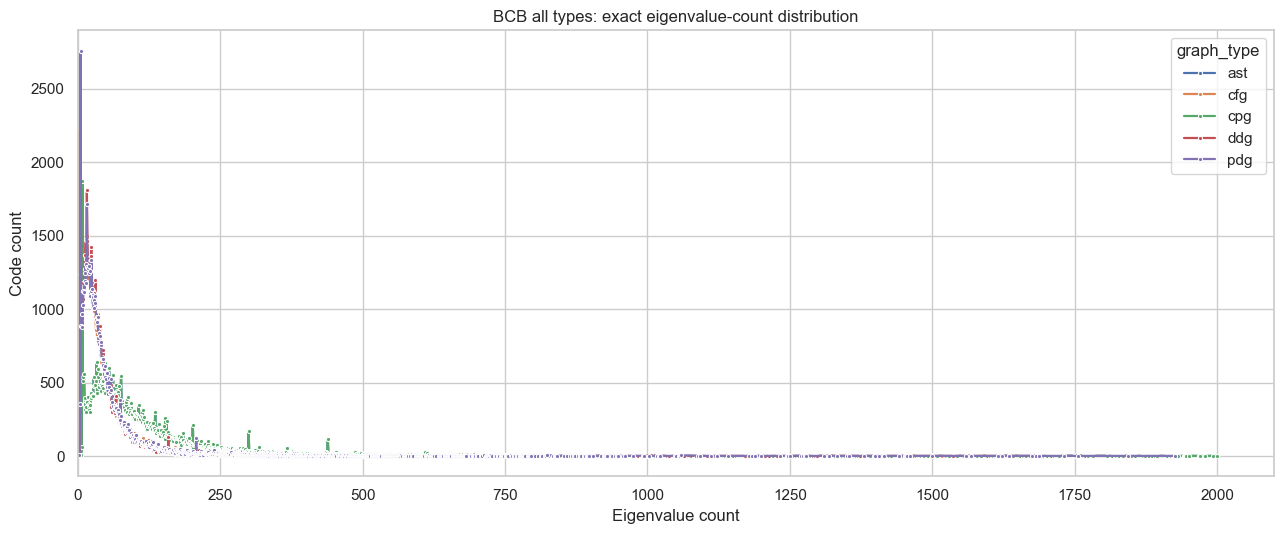

,graph_type,eigenvalue_count,code_count
0,ast,0,2
1,ast,6,5
2,ast,7,61
3,ast,8,1871
4,ast,9,511
5,ast,10,539
6,ast,11,557
7,ast,12,385
8,ast,13,395
9,ast,14,303


In [4]:
distribution_df = (
    counts_df
    .groupby(["graph_type", "eigenvalue_count"], as_index=False)
    .agg(code_count=("method_id", "count"))
    .sort_values(["graph_type", "eigenvalue_count"])
)

plt.figure(figsize=(13, 5.5))
sns.lineplot(
    data=distribution_df,
    x="eigenvalue_count",
    y="code_count",
    hue="graph_type",
    marker="o",
    linewidth=1.6,
    markersize=3,
)
plt.xlabel("Eigenvalue count")
plt.ylabel("Code count")
plt.title("BCB all types: exact eigenvalue-count distribution")
plt.xlim(left=0)
plt.tight_layout()
plt.show()

display(distribution_df.head(20))

## Survival: methods with at least X eigenvalues

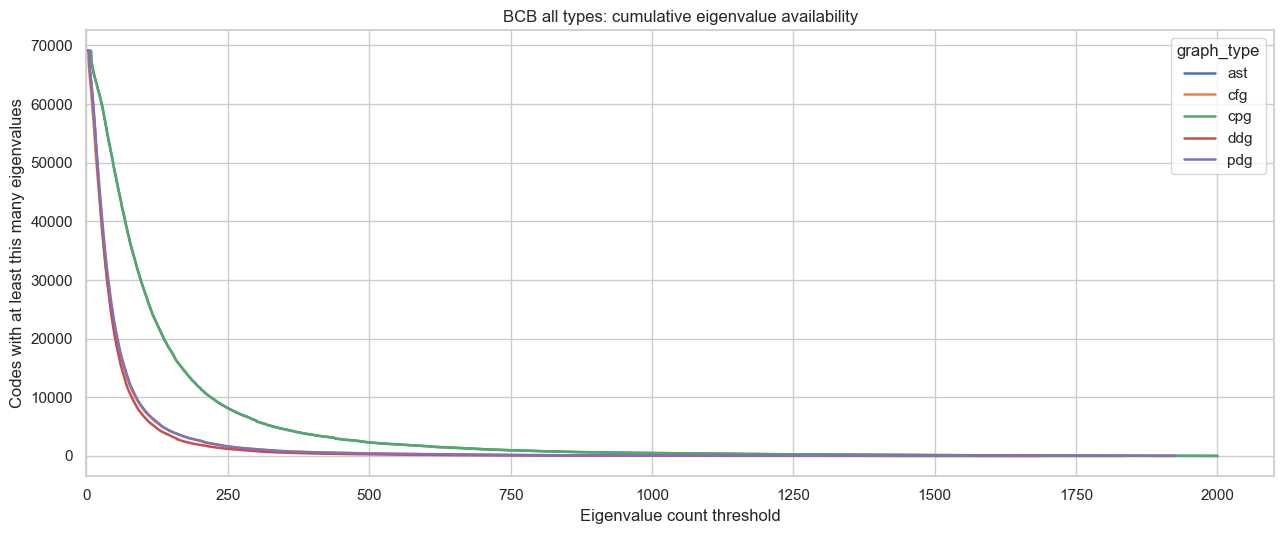

,eigenvalue_count,at_least_code_count,graph_type
0,0,69110,ast
5,5,69108,ast
10,10,66660,ast
20,20,62650,ast
30,30,58585,ast
50,50,48499,ast
100,100,28764,ast
2001,0,69110,cfg
2006,5,65604,cfg
2011,10,60044,cfg


In [5]:
def survival_counts(group: pd.DataFrame) -> pd.DataFrame:
    counts = np.sort(group["eigenvalue_count"].to_numpy(dtype=np.int64))
    if counts.size == 0:
        return pd.DataFrame(columns=["eigenvalue_count", "at_least_code_count"])
    xs = np.arange(0, int(counts.max()) + 1, dtype=np.int64)
    at_least = counts.size - np.searchsorted(counts, xs, side="left")
    return pd.DataFrame({"eigenvalue_count": xs, "at_least_code_count": at_least})

survival_parts = []
for graph_type, group in counts_df.groupby("graph_type"):
    part = survival_counts(group)
    part["graph_type"] = graph_type
    survival_parts.append(part)

survival_df = pd.concat(survival_parts, ignore_index=True)

plt.figure(figsize=(13, 5.5))
sns.lineplot(
    data=survival_df,
    x="eigenvalue_count",
    y="at_least_code_count",
    hue="graph_type",
    linewidth=1.8,
)
plt.xlabel("Eigenvalue count threshold")
plt.ylabel("Codes with at least this many eigenvalues")
plt.title("BCB all types: cumulative eigenvalue availability")
plt.xlim(left=0)
plt.tight_layout()
plt.show()

display(survival_df[survival_df["eigenvalue_count"].isin([0, 5, 10, 20, 30, 50, 100])].sort_values(["graph_type", "eigenvalue_count"]))

## Optional: per-source view before deduplication

In [6]:
per_source_summary_df = (
    raw_counts_df
    .groupby(["source_label", "graph_type"])
    .agg(
        rows=("method_id", "count"),
        unique_methods=("method_id", "nunique"),
        zero_eigenvalue_methods=("eigenvalue_count", lambda s: int((s == 0).sum())),
        median_eigenvalues=("eigenvalue_count", "median"),
        mean_eigenvalues=("eigenvalue_count", "mean"),
        max_eigenvalues=("eigenvalue_count", "max"),
    )
    .reset_index()
    .sort_values(["source_label", "graph_type"])
)

display(per_source_summary_df)

,source_label,graph_type,rows,unique_methods,zero_eigenvalue_methods,median_eigenvalues,mean_eigenvalues,max_eigenvalues
0,Non Clone,ast,55678,55678,1,78.0,127.947556,2000
1,Non Clone,cfg,55678,55678,1,30.0,51.880635,1835
2,Non Clone,cpg,55678,55678,1,78.0,127.947556,2000
3,Non Clone,ddg,55678,55678,5,30.0,48.166403,1689
4,Non Clone,pdg,55678,55678,1,31.0,53.706832,1926
5,Type 1,ast,3603,3603,0,88.0,139.253955,1749
6,Type 1,cfg,3603,3603,0,33.0,55.198168,665
7,Type 1,cpg,3603,3603,0,88.0,139.253955,1749
8,Type 1,ddg,3603,3603,0,31.0,50.247849,648
9,Type 1,pdg,3603,3603,0,35.0,56.305856,674


## Per-Type Counts Above Eigenvalue Thresholds

This section reports how many unique codes in each BCB type have at least 50, 75, and 100 eigenvalues. Type 3 is shown both as the merged `all` set and as its `moderate`, `strong`, and `very_strong` subsets.

In [7]:
THRESHOLD_VARIANTS = [
    {"label": "Type 1", "variant": "1"},
    {"label": "Type 2", "variant": "2"},
    {"label": "Type 3 All", "variant": "3/all"},
    {"label": "Type 3 Moderate", "variant": "3/moderate"},
    {"label": "Type 3 Strong", "variant": "3/strong"},
    {"label": "Type 3 Very Strong", "variant": "3/very_strong"},
    {"label": "Type 4", "variant": "4"},
    {"label": "Non Clone", "variant": "non_clone"},
]
EIGENVALUE_THRESHOLDS = [50, 75, 100]

threshold_manifest_df = pd.DataFrame([
    {
        "label": config["label"],
        "variant": config["variant"],
        "manifest_path": str(spectral_manifest_path(config["variant"])),
        "exists": spectral_manifest_path(config["variant"]).exists(),
    }
    for config in THRESHOLD_VARIANTS
])
display(threshold_manifest_df)

missing_threshold_manifests = threshold_manifest_df[~threshold_manifest_df["exists"]]
if not missing_threshold_manifests.empty:
    raise FileNotFoundError(
        "Missing spectral manifests:\n" + "\n".join(missing_threshold_manifests["manifest_path"])
    )

,label,variant,manifest_path,exists
0,Type 1,1,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
1,Type 2,2,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
2,Type 3 All,3/all,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
3,Type 3 Moderate,3/moderate,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
4,Type 3 Strong,3/strong,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
5,Type 3 Very Strong,3/very_strong,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
6,Type 4,4,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True
7,Non Clone,non_clone,C:\Users\koush\PyProjects\spectrals\outputs\bc...,True


In [8]:
threshold_rows = []
for config in THRESHOLD_VARIANTS:
    threshold_rows.extend(iter_spectral_count_rows(config))

threshold_raw_df = pd.DataFrame(threshold_rows)

threshold_counts_df = (
    threshold_raw_df
    .groupby(["source_label", "source_variant", "method_id", "graph_type"], as_index=False)
    .agg(eigenvalue_count=("eigenvalue_count", "max"))
)

display(threshold_counts_df.head())

Loading Non Clone: 100%|██████████| 56/56 [00:04<00:00, 13.60shard/s]


,source_label,source_variant,method_id,graph_type,eigenvalue_count
0,Non Clone,non_clone,10000061,ast,124
1,Non Clone,non_clone,10000061,cfg,46
2,Non Clone,non_clone,10000061,cpg,124
3,Non Clone,non_clone,10000061,ddg,38
4,Non Clone,non_clone,10000061,pdg,43


In [9]:
per_graph_threshold_rows = []
for (source_label, source_variant, graph_type), group in threshold_counts_df.groupby(["source_label", "source_variant", "graph_type"]):
    total_codes = int(group["method_id"].nunique())
    row = {
        "source_label": source_label,
        "source_variant": source_variant,
        "graph_type": graph_type,
        "total_codes": total_codes,
    }
    for threshold in EIGENVALUE_THRESHOLDS:
        count = int(group.loc[group["eigenvalue_count"] >= threshold, "method_id"].nunique())
        row[f"at_least_{threshold}"] = count
        row[f"at_least_{threshold}_fraction"] = count / total_codes if total_codes else 0.0
    per_graph_threshold_rows.append(row)

per_graph_threshold_df = (
    pd.DataFrame(per_graph_threshold_rows)
    .sort_values(["source_variant", "graph_type"])
    .reset_index(drop=True)
)

display(per_graph_threshold_df)

,source_label,source_variant,graph_type,total_codes,at_least_50,at_least_50_fraction,at_least_75,at_least_75_fraction,at_least_100,at_least_100_fraction
0,Type 1,1,ast,3603,2869,0.796281,2046,0.567860,1589,0.441021
1,Type 1,1,cfg,3603,1129,0.313350,666,0.184846,497,0.137941
2,Type 1,1,cpg,3603,2869,0.796281,2046,0.567860,1589,0.441021
3,Type 1,1,ddg,3603,1062,0.294754,620,0.172079,446,0.123786
4,Type 1,1,pdg,3603,1158,0.321399,698,0.193727,515,0.142936
5,Type 2,2,ast,953,636,0.667366,465,0.487933,348,0.365163
6,Type 2,2,cfg,953,150,0.157398,84,0.088143,56,0.058762
7,Type 2,2,cpg,953,636,0.667366,465,0.487933,348,0.365163
8,Type 2,2,ddg,953,119,0.124869,73,0.076600,52,0.054565
9,Type 2,2,pdg,953,154,0.161595,86,0.090241,66,0.069255


In [10]:
per_code_max_df = (
    threshold_counts_df
    .groupby(["source_label", "source_variant", "method_id"], as_index=False)
    .agg(
        max_eigenvalue_count=("eigenvalue_count", "max"),
        min_eigenvalue_count=("eigenvalue_count", "min"),
    )
)

per_type_threshold_rows = []
for (source_label, source_variant), group in per_code_max_df.groupby(["source_label", "source_variant"]):
    total_codes = int(group["method_id"].nunique())
    row = {
        "source_label": source_label,
        "source_variant": source_variant,
        "total_codes": total_codes,
    }
    for threshold in EIGENVALUE_THRESHOLDS:
        any_graph_count = int(group.loc[group["max_eigenvalue_count"] >= threshold, "method_id"].nunique())
        all_graphs_count = int(group.loc[group["min_eigenvalue_count"] >= threshold, "method_id"].nunique())
        row[f"any_graph_at_least_{threshold}"] = any_graph_count
        row[f"any_graph_at_least_{threshold}_fraction"] = any_graph_count / total_codes if total_codes else 0.0
        row[f"all_graphs_at_least_{threshold}"] = all_graphs_count
        row[f"all_graphs_at_least_{threshold}_fraction"] = all_graphs_count / total_codes if total_codes else 0.0
    per_type_threshold_rows.append(row)

per_type_threshold_df = (
    pd.DataFrame(per_type_threshold_rows)
    .sort_values("source_variant")
    .reset_index(drop=True)
)

display(per_type_threshold_df)

,source_label,source_variant,total_codes,any_graph_at_least_50,any_graph_at_least_50_fraction,all_graphs_at_least_50,all_graphs_at_least_50_fraction,any_graph_at_least_75,any_graph_at_least_75_fraction,all_graphs_at_least_75,all_graphs_at_least_75_fraction,any_graph_at_least_100,any_graph_at_least_100_fraction,all_graphs_at_least_100,all_graphs_at_least_100_fraction
0,Type 1,1,3603,2869,0.796281,1047,0.290591,2046,0.567860,614,0.170414,1589,0.441021,433,0.120178
1,Type 2,2,953,636,0.667366,117,0.122770,465,0.487933,73,0.076600,348,0.365163,50,0.052466
2,Type 3 All,3/all,9039,6973,0.771435,1664,0.184091,4655,0.514991,843,0.093263,3113,0.344397,515,0.056975
3,Type 3 Moderate,3/moderate,7654,5627,0.735171,981,0.128168,3536,0.461981,415,0.054220,2189,0.285994,218,0.028482
4,Type 3 Strong,3/strong,4640,3389,0.730388,813,0.175216,2186,0.471121,440,0.094828,1556,0.335345,267,0.057543
5,Type 3 Very Strong,3/very_strong,1744,1582,0.907110,555,0.318234,1207,0.692087,315,0.180619,924,0.529817,222,0.127294
6,Type 4,4,14119,11798,0.835612,4366,0.309229,8882,0.629081,2428,0.171967,6701,0.474609,1560,0.110489
7,Non Clone,non_clone,55678,37249,0.669008,15461,0.277686,28891,0.518894,8412,0.151083,22422,0.402708,5276,0.094759


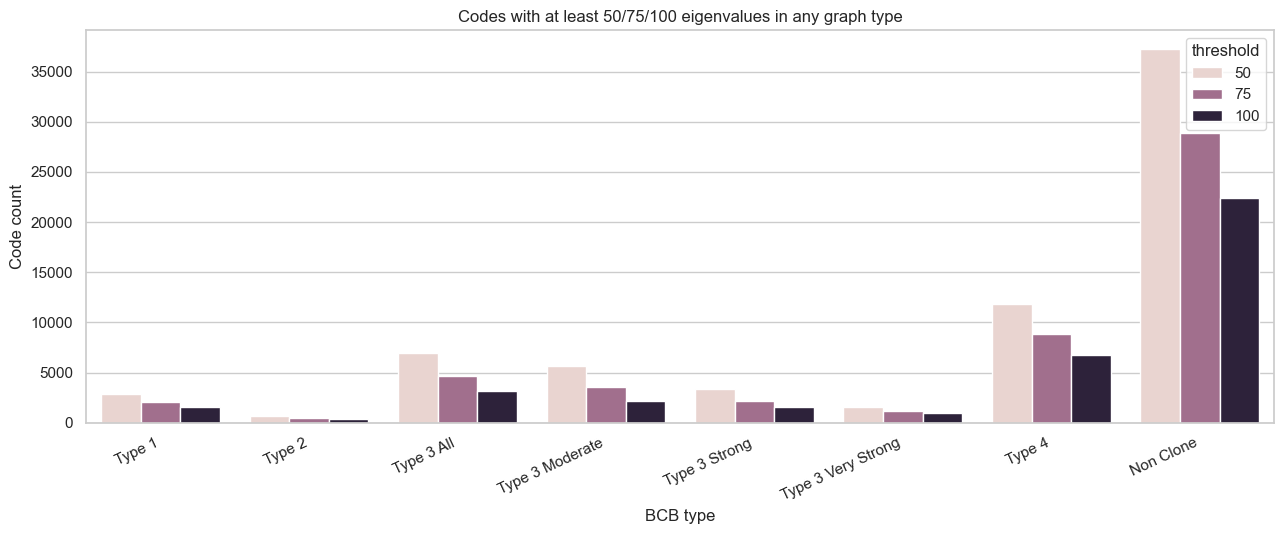

,source_label,source_variant,threshold,code_count,criterion
1,Type 1,1,50,1047,all graphs
3,Type 1,1,75,614,all graphs
5,Type 1,1,100,433,all graphs
0,Type 1,1,50,2869,any graph
2,Type 1,1,75,2046,any graph
4,Type 1,1,100,1589,any graph
7,Type 2,2,50,117,all graphs
9,Type 2,2,75,73,all graphs
11,Type 2,2,100,50,all graphs
6,Type 2,2,50,636,any graph


In [11]:
plot_rows = []
for _, row in per_type_threshold_df.iterrows():
    for threshold in EIGENVALUE_THRESHOLDS:
        plot_rows.append({
            "source_label": row["source_label"],
            "source_variant": row["source_variant"],
            "threshold": threshold,
            "code_count": row[f"any_graph_at_least_{threshold}"],
            "criterion": "any graph",
        })
        plot_rows.append({
            "source_label": row["source_label"],
            "source_variant": row["source_variant"],
            "threshold": threshold,
            "code_count": row[f"all_graphs_at_least_{threshold}"],
            "criterion": "all graphs",
        })

threshold_plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(13, 5.5))
sns.barplot(
    data=threshold_plot_df[threshold_plot_df["criterion"] == "any graph"],
    x="source_label",
    y="code_count",
    hue="threshold",
)
plt.xlabel("BCB type")
plt.ylabel("Code count")
plt.title("Codes with at least 50/75/100 eigenvalues in any graph type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(threshold_plot_df.sort_values(["source_variant", "criterion", "threshold"]))

## Pair Counts Above Eigenvalue Thresholds

This section counts pairs where both methods have at least 50, 75, and 100 eigenvalues. The per-graph table checks the condition separately for AST/CFG/DDG/PDG/CPG. The per-type table also reports whether each pair passes the threshold in any shared graph type or in all graph types.

In [12]:
from spectral_code.utils.dataset_paths import bcb_type_dir

def pair_file_path(variant: str) -> Path:
    return bcb_type_dir(variant) / "train.txt"

pair_manifest_df = pd.DataFrame([
    {
        "label": config["label"],
        "variant": config["variant"],
        "pair_path": str(pair_file_path(config["variant"])),
        "exists": pair_file_path(config["variant"]).exists(),
    }
    for config in THRESHOLD_VARIANTS
])
display(pair_manifest_df)

missing_pair_files = pair_manifest_df[~pair_manifest_df["exists"]]
if not missing_pair_files.empty:
    raise FileNotFoundError("Missing pair files:\n" + "\n".join(missing_pair_files["pair_path"]))

,label,variant,pair_path,exists
0,Type 1,1,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
1,Type 2,2,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
2,Type 3 All,3/all,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
3,Type 3 Moderate,3/moderate,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
4,Type 3 Strong,3/strong,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
5,Type 3 Very Strong,3/very_strong,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
6,Type 4,4,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,True
7,Non Clone,non_clone,C:\Users\koush\PyProjects\spectrals\data\bcb\n...,True


In [13]:
def iter_pair_file(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            yield str(parts[0]), str(parts[1]), str(parts[2])

count_lookup_by_variant = {}
for variant, variant_df in threshold_counts_df.groupby("source_variant"):
    count_lookup_by_variant[variant] = {
        graph_type: dict(zip(graph_df["method_id"].astype(str), graph_df["eigenvalue_count"].astype(int)))
        for graph_type, graph_df in variant_df.groupby("graph_type")
    }

per_graph_pair_rows = []
per_type_pair_rows = []

for config in THRESHOLD_VARIANTS:
    source_label = config["label"]
    source_variant = config["variant"]
    graph_lookups = count_lookup_by_variant.get(source_variant, {})
    path = pair_file_path(source_variant)

    total_pairs = 0
    label_counts = Counter()
    missing_method_pairs = 0
    per_graph_hits = {
        graph_type: {threshold: 0 for threshold in EIGENVALUE_THRESHOLDS}
        for graph_type in GRAPH_TYPES
    }
    any_shared_graph_hits = {threshold: 0 for threshold in EIGENVALUE_THRESHOLDS}
    all_graph_hits = {threshold: 0 for threshold in EIGENVALUE_THRESHOLDS}

    for left_id, right_id, label in tqdm(iter_pair_file(path), desc=f"Pair thresholds {source_label}", unit="pair"):
        total_pairs += 1
        label_counts[label] += 1

        left_counts = {
            graph_type: graph_lookups.get(graph_type, {}).get(left_id, 0)
            for graph_type in GRAPH_TYPES
        }
        right_counts = {
            graph_type: graph_lookups.get(graph_type, {}).get(right_id, 0)
            for graph_type in GRAPH_TYPES
        }
        if not any(left_counts.values()) or not any(right_counts.values()):
            missing_method_pairs += 1

        for threshold in EIGENVALUE_THRESHOLDS:
            graph_passes = []
            for graph_type in GRAPH_TYPES:
                passes = left_counts[graph_type] >= threshold and right_counts[graph_type] >= threshold
                graph_passes.append(passes)
                if passes:
                    per_graph_hits[graph_type][threshold] += 1
            if any(graph_passes):
                any_shared_graph_hits[threshold] += 1
            if all(graph_passes):
                all_graph_hits[threshold] += 1

    for graph_type in GRAPH_TYPES:
        row = {
            "source_label": source_label,
            "source_variant": source_variant,
            "graph_type": graph_type,
            "total_pairs": total_pairs,
            "label_counts": dict(label_counts),
            "pairs_with_missing_method_spectral": missing_method_pairs,
        }
        for threshold in EIGENVALUE_THRESHOLDS:
            count = per_graph_hits[graph_type][threshold]
            row[f"both_at_least_{threshold}"] = count
            row[f"both_at_least_{threshold}_fraction"] = count / total_pairs if total_pairs else 0.0
        per_graph_pair_rows.append(row)

    type_row = {
        "source_label": source_label,
        "source_variant": source_variant,
        "total_pairs": total_pairs,
        "label_counts": dict(label_counts),
        "pairs_with_missing_method_spectral": missing_method_pairs,
    }
    for threshold in EIGENVALUE_THRESHOLDS:
        any_count = any_shared_graph_hits[threshold]
        all_count = all_graph_hits[threshold]
        type_row[f"any_shared_graph_both_at_least_{threshold}"] = any_count
        type_row[f"any_shared_graph_both_at_least_{threshold}_fraction"] = any_count / total_pairs if total_pairs else 0.0
        type_row[f"all_graphs_both_at_least_{threshold}"] = all_count
        type_row[f"all_graphs_both_at_least_{threshold}_fraction"] = all_count / total_pairs if total_pairs else 0.0
    per_type_pair_rows.append(type_row)

per_graph_pair_threshold_df = (
    pd.DataFrame(per_graph_pair_rows)
    .sort_values(["source_variant", "graph_type"])
    .reset_index(drop=True)
)
per_type_pair_threshold_df = (
    pd.DataFrame(per_type_pair_rows)
    .sort_values("source_variant")
    .reset_index(drop=True)
)

display(per_graph_pair_threshold_df)
display(per_type_pair_threshold_df)

Pair thresholds Type 1: 45873pair [00:00, 108434.32pair/s]
Pair thresholds Type 2: 4106pair [00:00, 136982.19pair/s]
Pair thresholds Type 3 All: 105965pair [00:00, 130280.53pair/s]
Pair thresholds Type 3 Moderate: 86041pair [00:00, 118219.64pair/s]
Pair thresholds Type 3 Strong: 16716pair [00:00, 133997.64pair/s]
Pair thresholds Type 3 Very Strong: 3208pair [00:00, 119583.78pair/s]
Pair thresholds Type 4: 939436pair [00:09, 100650.19pair/s]
Pair thresholds Non Clone: 260708pair [00:02, 130046.91pair/s]


,source_label,source_variant,graph_type,total_pairs,label_counts,pairs_with_missing_method_spectral,both_at_least_50,both_at_least_50_fraction,both_at_least_75,both_at_least_75_fraction,both_at_least_100,both_at_least_100_fraction
0,Type 1,1,ast,45873,{'1': 45873},0,32917,0.717568,18421,0.401565,17497,0.381423
1,Type 1,1,cfg,45873,{'1': 45873},0,12958,0.282476,7039,0.153445,6605,0.143984
2,Type 1,1,cpg,45873,{'1': 45873},0,32917,0.717568,18421,0.401565,17497,0.381423
3,Type 1,1,ddg,45873,{'1': 45873},0,12552,0.273625,6987,0.152312,6474,0.141129
4,Type 1,1,pdg,45873,{'1': 45873},0,12979,0.282933,7095,0.154666,6634,0.144617
5,Type 2,2,ast,4106,{'1': 4106},1,3337,0.812713,3174,0.773015,3039,0.740136
6,Type 2,2,cfg,4106,{'1': 4106},1,151,0.036775,71,0.017292,55,0.013395
7,Type 2,2,cpg,4106,{'1': 4106},1,3337,0.812713,3174,0.773015,3039,0.740136
8,Type 2,2,ddg,4106,{'1': 4106},1,95,0.023137,64,0.015587,53,0.012908
9,Type 2,2,pdg,4106,{'1': 4106},1,153,0.037263,72,0.017535,60,0.014613


,source_label,source_variant,total_pairs,label_counts,pairs_with_missing_method_spectral,any_shared_graph_both_at_least_50,any_shared_graph_both_at_least_50_fraction,all_graphs_both_at_least_50,all_graphs_both_at_least_50_fraction,any_shared_graph_both_at_least_75,any_shared_graph_both_at_least_75_fraction,all_graphs_both_at_least_75,all_graphs_both_at_least_75_fraction,any_shared_graph_both_at_least_100,any_shared_graph_both_at_least_100_fraction,all_graphs_both_at_least_100,all_graphs_both_at_least_100_fraction
0,Type 1,1,45873,{'1': 45873},0,32917,0.717568,12543,0.273429,18421,0.401565,6984,0.152246,17497,0.381423,6462,0.140867
1,Type 2,2,4106,{'1': 4106},1,3337,0.812713,94,0.022893,3174,0.773015,64,0.015587,3039,0.740136,52,0.012664
2,Type 3 All,3/all,105965,{'1': 105965},0,60316,0.569207,4316,0.040730,23835,0.224933,2096,0.019780,12574,0.118662,1400,0.013212
3,Type 3 Moderate,3/moderate,86041,{'1': 86041},0,47168,0.548204,1541,0.017910,15608,0.181402,472,0.005486,6084,0.070710,157,0.001825
4,Type 3 Strong,3/strong,16716,{'1': 16716},0,10202,0.610313,1942,0.116176,6227,0.372517,1037,0.062036,4888,0.292414,752,0.044987
5,Type 3 Very Strong,3/very_strong,3208,{'1': 3208},0,2946,0.918329,833,0.259663,2000,0.623441,587,0.182980,1602,0.499377,491,0.153055
6,Type 4,4,939436,{'1': 939436},0,683103,0.727142,111728,0.118931,424585,0.451957,34257,0.036465,261624,0.278490,14101,0.015010
7,Non Clone,non_clone,260708,{'0': 260708},0,75746,0.290540,0,0.000000,12922,0.049565,0,0.000000,5672,0.021756,0,0.000000


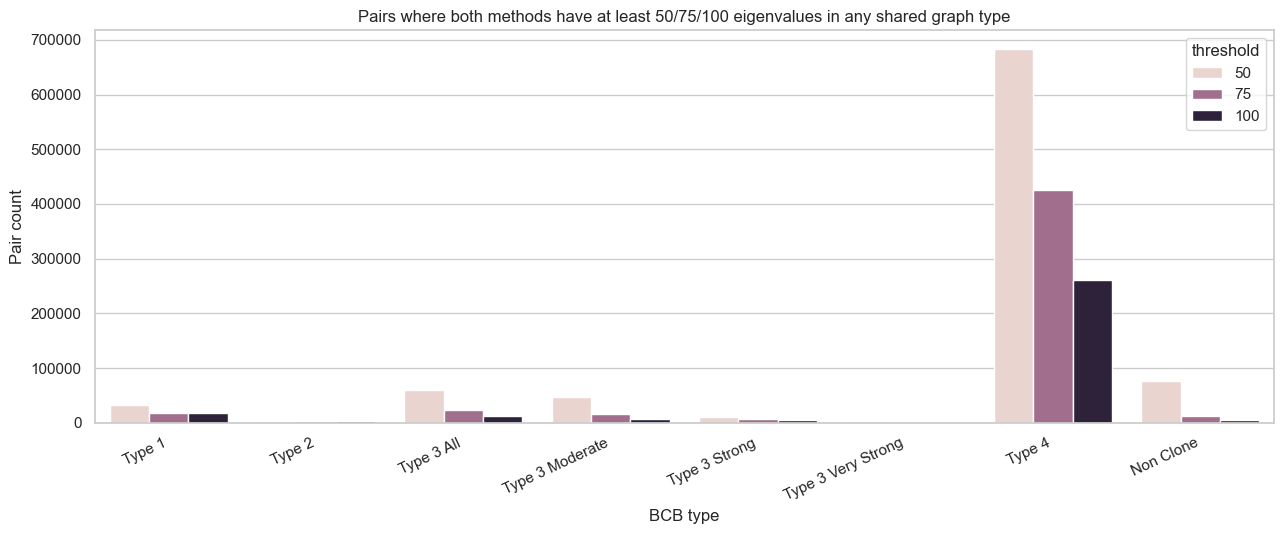

,source_label,source_variant,threshold,pair_count,criterion
1,Type 1,1,50,12543,all graphs
3,Type 1,1,75,6984,all graphs
5,Type 1,1,100,6462,all graphs
0,Type 1,1,50,32917,any shared graph
2,Type 1,1,75,18421,any shared graph
4,Type 1,1,100,17497,any shared graph
7,Type 2,2,50,94,all graphs
9,Type 2,2,75,64,all graphs
11,Type 2,2,100,52,all graphs
6,Type 2,2,50,3337,any shared graph


In [14]:
pair_plot_rows = []
for _, row in per_type_pair_threshold_df.iterrows():
    for threshold in EIGENVALUE_THRESHOLDS:
        pair_plot_rows.append({
            "source_label": row["source_label"],
            "source_variant": row["source_variant"],
            "threshold": threshold,
            "pair_count": row[f"any_shared_graph_both_at_least_{threshold}"],
            "criterion": "any shared graph",
        })
        pair_plot_rows.append({
            "source_label": row["source_label"],
            "source_variant": row["source_variant"],
            "threshold": threshold,
            "pair_count": row[f"all_graphs_both_at_least_{threshold}"],
            "criterion": "all graphs",
        })

pair_threshold_plot_df = pd.DataFrame(pair_plot_rows)

plt.figure(figsize=(13, 5.5))
sns.barplot(
    data=pair_threshold_plot_df[pair_threshold_plot_df["criterion"] == "any shared graph"],
    x="source_label",
    y="pair_count",
    hue="threshold",
)
plt.xlabel("BCB type")
plt.ylabel("Pair count")
plt.title("Pairs where both methods have at least 50/75/100 eigenvalues in any shared graph type")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(pair_threshold_plot_df.sort_values(["source_variant", "criterion", "threshold"]))